In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('C:/.vscode/jupiter/main/W0/data/benin-malanville.csv')
sns.set(style="whitegrid", rc={"figure.figsize": (10,5)})

In [3]:
data.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [4]:
data.shape

(525600, 19)

In [5]:
# Summary Statistics 
data.describe() 

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


In [6]:
# list any column with > 5% nulls.
data.isna().sum() 

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  str    
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-null  float64


In [8]:
data[['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']].describe()

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,240.559452,167.187516,115.358961,236.589496,228.883576,2.121113,2.809195
std,331.131327,261.710501,158.691074,326.894859,316.536515,1.603466,2.029120
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,0.000000,0.000000
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,1.000000,1.300000
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,1.900000,2.600000
75%,483.400000,314.200000,216.300000,463.700000,447.900000,3.100000,4.100000
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,19.500000,26.600000


In [9]:
data.dtypes

Timestamp            str
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

In [10]:
clean_data = data.copy()
clean_data = clean_data.dropna()


In [11]:
display(data.describe(include='all'))

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
unique,525600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2021-08-09 00:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,NaN,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,NaN,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,NaN,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,NaN,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,NaN,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN


In [12]:
missing = data.isna().sum()
missing_pct = 100 * missing / len(data)
print(missing_pct)

Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64


In [13]:
# adapt column name if different
ts_col = 'Timestamp'
data[ts_col] = pd.to_datetime(data[ts_col], errors='coerce')
data = data.sort_values(ts_col)
data.set_index(ts_col, inplace=True) 

In [14]:
data.head()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [15]:
data.dtypes

GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

In [16]:
data.head()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [17]:
data.keys()

Index(['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust',
       'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA',
       'TModB', 'Comments'],
      dtype='str')

In [18]:
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS','WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB']
data[key_cols].describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000


In [19]:
data.isna().sum()/len(data)*100

GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64

In [20]:
key_cols = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']
zs = np.abs(stats.zscore(data[key_cols].dropna()))  # drops rows with NA in these cols for z-score calc

outlier_mask = (zs > 3).any(axis=1)
data['is_outlier'] = outlier_mask
data['n_outlier_cols'] = (zs <= 3).sum(axis=1)
outlier_count = data['is_outlier'].sum()
outlier_count, f"{outlier_count/len(data):.2%} of rows flagged as outliers" 

(np.int64(7740), '1.47% of rows flagged as outliers')

In [21]:
print(data[['is_outlier', 'n_outlier_cols']][data["is_outlier"]==True].head())

                     is_outlier  n_outlier_cols
Timestamp                                      
2021-08-09 11:11:00        True               6
2021-08-09 11:12:00        True               4
2021-08-09 11:13:00        True               6
2021-08-09 11:14:00        True               6
2021-08-09 11:15:00        True               3


In [22]:
data[data["is_outlier"] == True].count()

GHI               7740
DNI               7740
DHI               7740
ModA              7740
ModB              7740
Tamb              7740
RH                7740
WS                7740
WSgust            7740
WSstdev           7740
WD                7740
WDstdev           7740
BP                7740
Cleaning          7740
Precipitation     7740
TModA             7740
TModB             7740
Comments             0
is_outlier        7740
n_outlier_cols    7740
dtype: int64

In [23]:
clean = data.copy()

# Option A: median-impute key columns
for c in key_cols:
    if c in clean.columns:
        clean[c] = clean[c].fillna(clean[c].median())

# Option B (optional): drop rows where essential irradiance missing
# clean = clean.dropna(subset=['GHI','DNI','DHI'])

# Remove extreme outlier rows if you choose
clean = clean[~clean['is_outlier']]

# quick check
clean[key_cols].describe()

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
count,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000,517860.000000
mean,236.234508,166.896673,111.656477,232.393310,225.026584,2.065886,2.737151
std,328.288787,262.081997,153.099749,324.256767,314.315996,1.513137,1.907636
min,-11.100000,-7.800000,-12.600000,0.000000,0.000000,0.000000,0.000000
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,0.900000,1.300000
50%,0.700000,-0.100000,0.500000,3.400000,3.200000,1.900000,2.400000
75%,468.700000,316.300000,212.000000,448.700000,434.000000,3.000000,3.900000
max,1233.000000,952.300000,591.400000,1205.100000,1175.000000,6.900000,8.700000


In [24]:
data.columns

Index(['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust',
       'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA',
       'TModB', 'Comments', 'is_outlier', 'n_outlier_cols'],
      dtype='str')

In [25]:
clean.reset_index().to_csv('../data/benin_clean.csv', index=False)

In [26]:
clean.head()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,is_outlier,n_outlier_cols
Timestamp,,,,,,,,,,,,,,,,,,,,
2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN,False,7
2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN,False,7
2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN,False,7
2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN,False,7
2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN,False,7


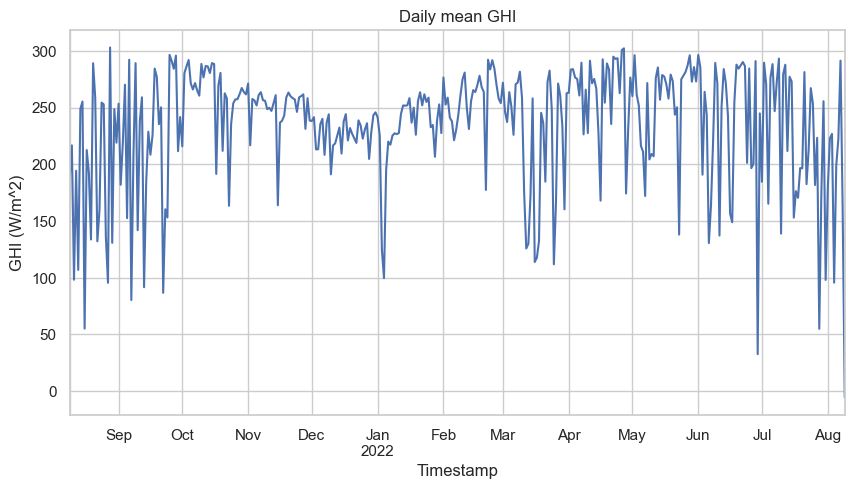

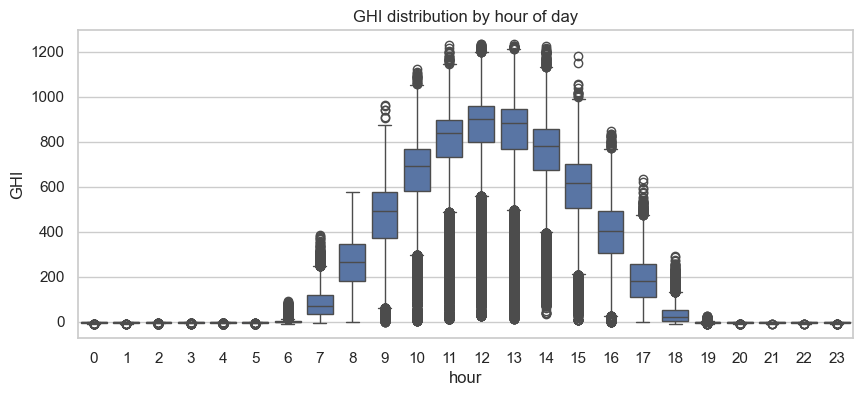

In [27]:
# daily mean
daily = clean.resample('D').mean()

plt.figure()
daily['GHI'].plot(title='Daily mean GHI')
plt.ylabel('GHI (W/m^2)')
plt.show()

# hourly pattern (boxplot by hour of day)
clean['hour'] = clean.index.hour
plt.figure(figsize=(10,4))
sns.boxplot(x='hour', y='GHI', data=clean.reset_index())
plt.title('GHI distribution by hour of day')
plt.show()


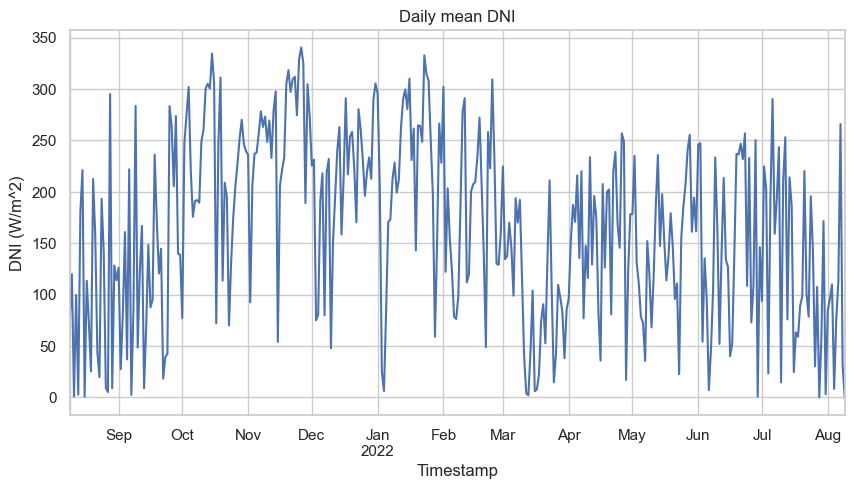

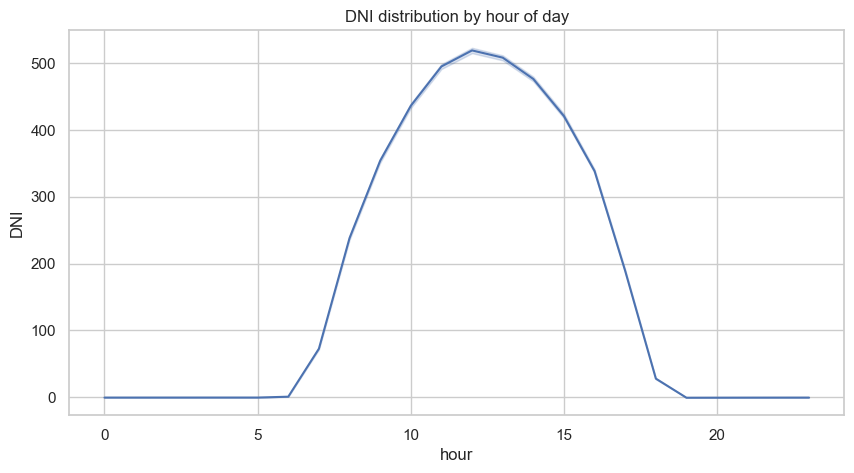

In [28]:
plt.figure()
daily["DNI"].plot(title='Daily mean DNI')
plt.ylabel('DNI (W/m^2)')
plt.show()

plt.figure()
sns.lineplot(x='hour', y='DNI', data=clean.reset_index())
plt.title('DNI distribution by hour of day')
plt.show()


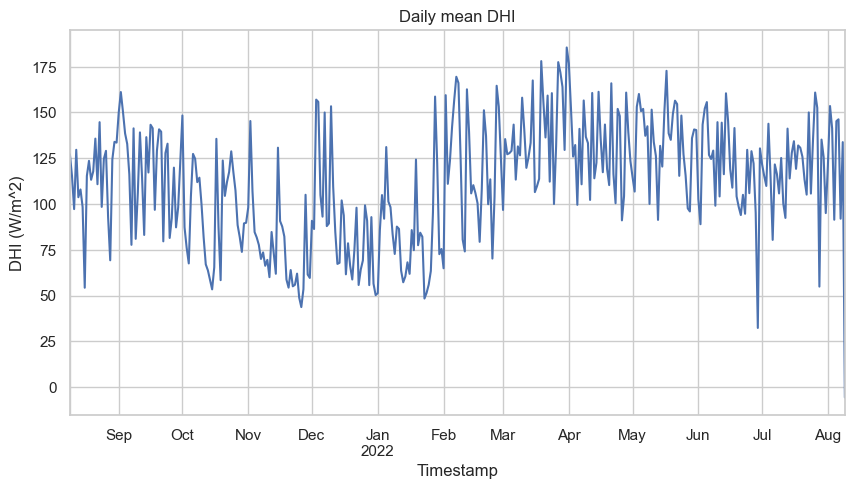

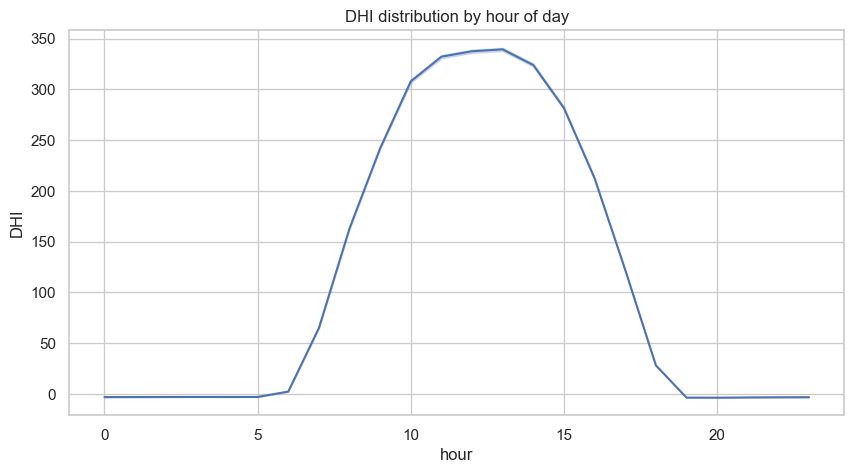

In [29]:
plt.figure()
daily["DHI"].plot(title='Daily mean DHI')
plt.ylabel('DHI (W/m^2)')
plt.show()

plt.figure()
sns.lineplot(x='hour', y='DHI', data=clean.reset_index())
plt.title('DHI distribution by hour of day')
plt.show()

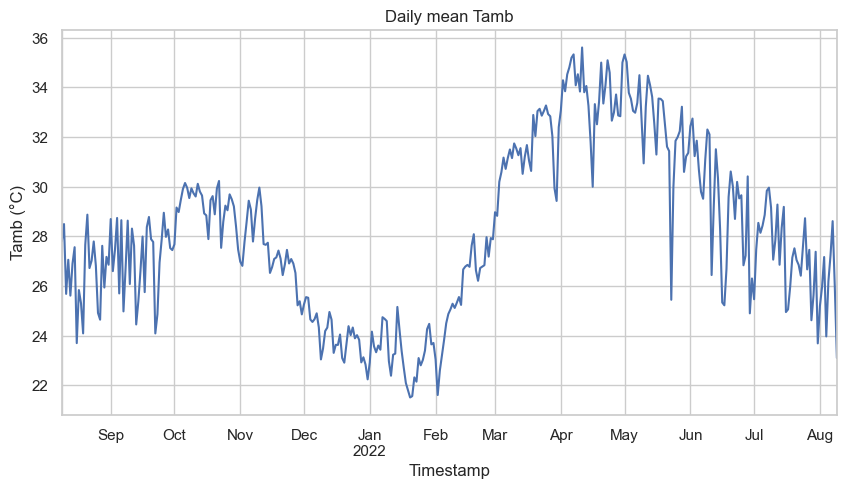

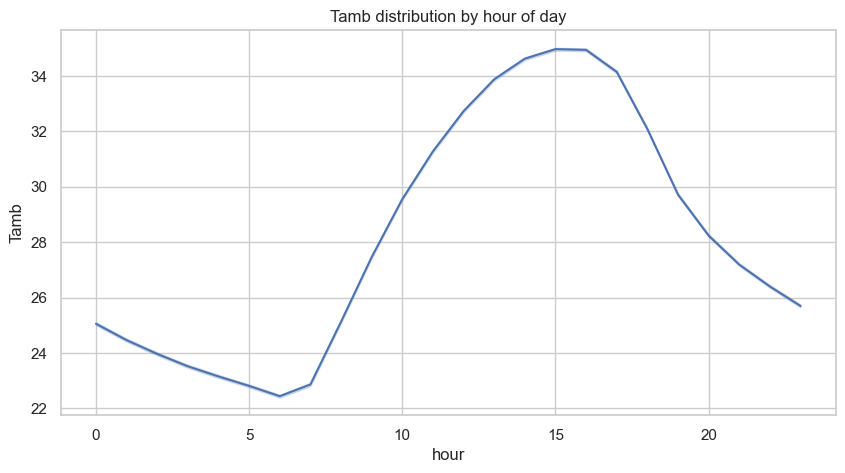

In [30]:
plt.figure()
daily["Tamb"].plot(title='Daily mean Tamb')
plt.ylabel('Tamb (°C)')
plt.show()

plt.figure()
sns.lineplot(x='hour', y='Tamb', data=clean.reset_index())
plt.title('Tamb distribution by hour of day')
plt.show()

,ModA,ModB
Cleaning,,
0,232.323881,224.95509
1,306.610124,301.45000


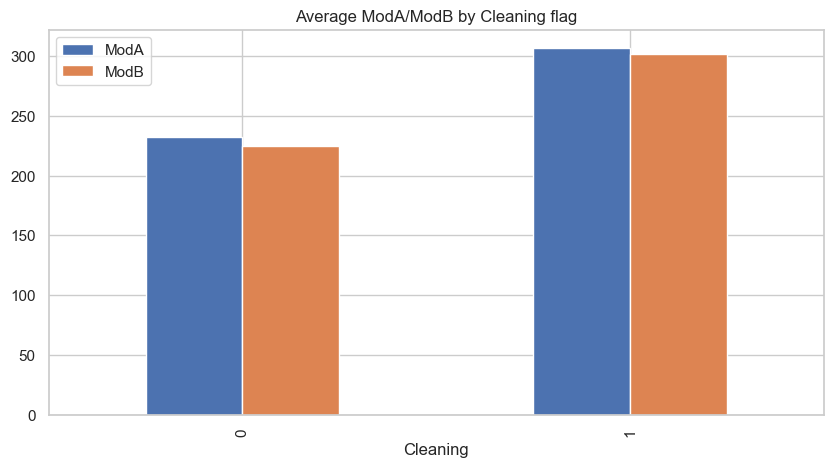

In [31]:
if 'Cleaning' in clean.columns:
    grp = clean.reset_index().groupby('Cleaning')[['ModA','ModB']].mean()
    display(grp)
    grp.plot(kind='bar', title='Average ModA/ModB by Cleaning flag')
    plt.show()

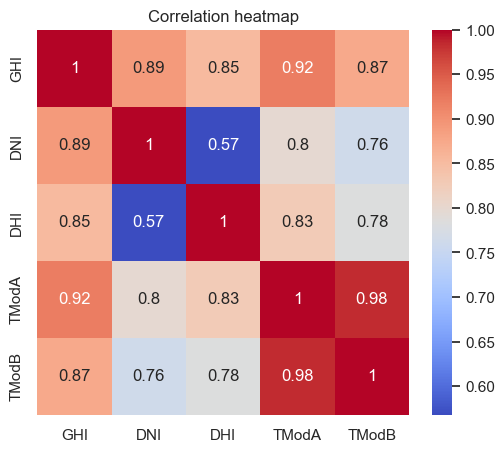

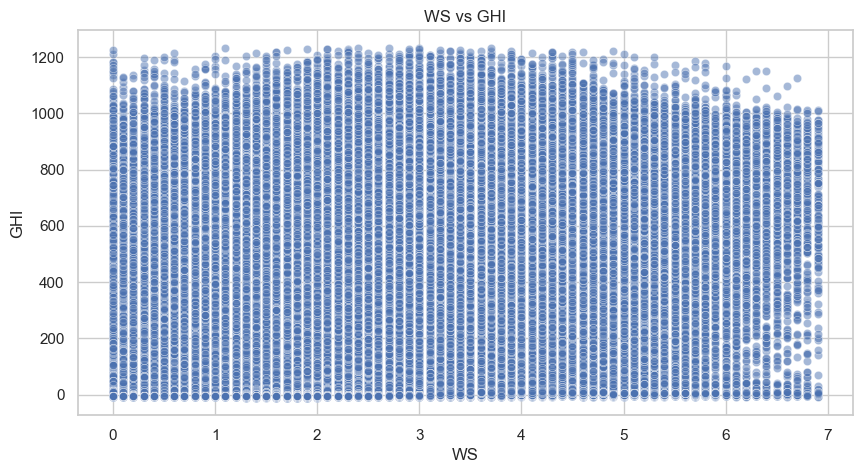

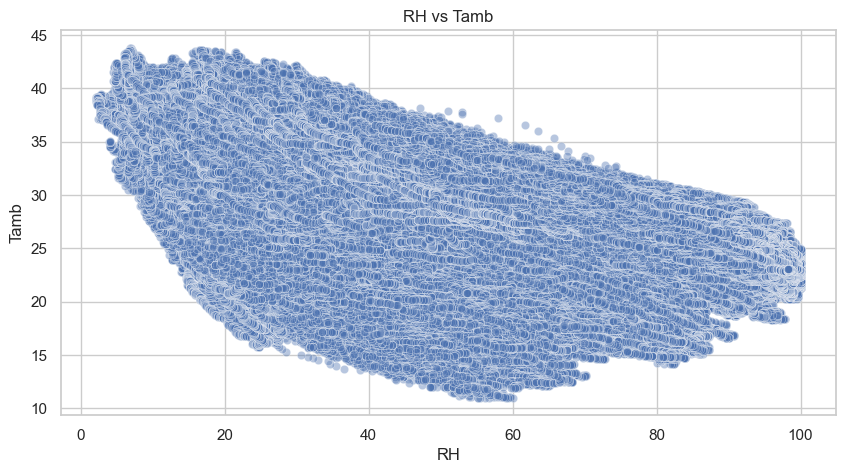

In [32]:
corr_cols = ['GHI','DNI','DHI','TModA','TModB'] 
plt.figure(figsize=(6,5))
sns.heatmap(clean[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

# scatter examples
sns.scatterplot(x='WS', y='GHI', data=clean, alpha=0.5)
plt.title('WS vs GHI')
plt.show()

sns.scatterplot(x='RH', y='Tamb', data=clean, alpha=0.4)
plt.title('RH vs Tamb')
plt.show()

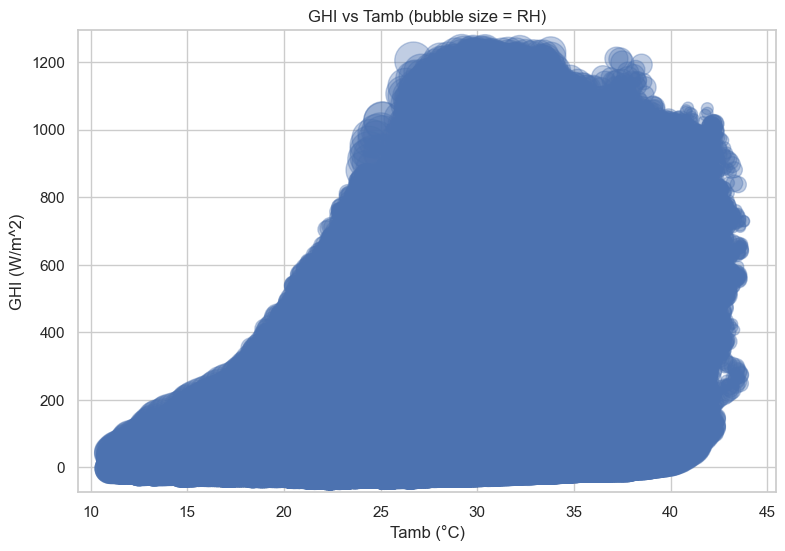

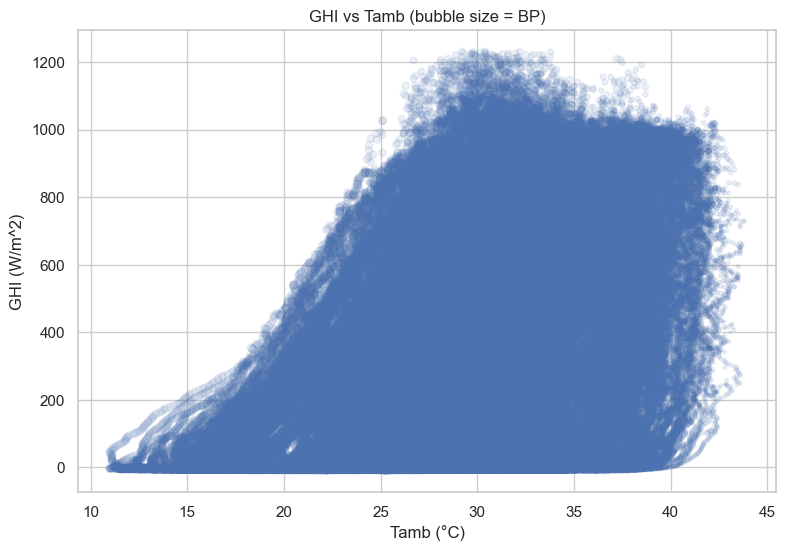

In [33]:
## Bubble Chart (`GHI` vs `Tamb`, bubble size = `RH` or `BP`)
plt.figure(figsize=(9,6))
sizes = (clean['RH'].fillna(0).clip(0,100) + 1) * 8   # bubble size from RH
plt.scatter(clean['Tamb'], clean['GHI'], s=sizes, alpha=0.35)
plt.xlabel('Tamb (°C)')
plt.ylabel('GHI (W/m^2)')
plt.title('GHI vs Tamb (bubble size = RH)')
plt.show()

sizes_bp = (clean['BP'].fillna(clean['BP'].median()) - clean['BP'].min() + 1) * 2
plt.figure(figsize=(9,6))
plt.scatter(clean['Tamb'], clean['GHI'], s=sizes_bp, alpha=0.1)
plt.xlabel('Tamb (°C)')
plt.ylabel('GHI (W/m^2)')
plt.title('GHI vs Tamb (bubble size = BP)')
plt.show()